In [1]:
!pip install numpy
!pip install pandas

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv('AirPassengers.csv')

In [3]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
data.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [5]:
data.dtypes

Month          object
#Passengers     int64
dtype: object

In [6]:
data['Month']=pd.to_datetime(data['Month'])

In [7]:
data.dtypes

Month          datetime64[ns]
#Passengers             int64
dtype: object

In [8]:
data.set_index('Month',inplace=True)

In [9]:
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [10]:
y=data.iloc[:,-1]

In [11]:
y

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, Length: 144, dtype: int64

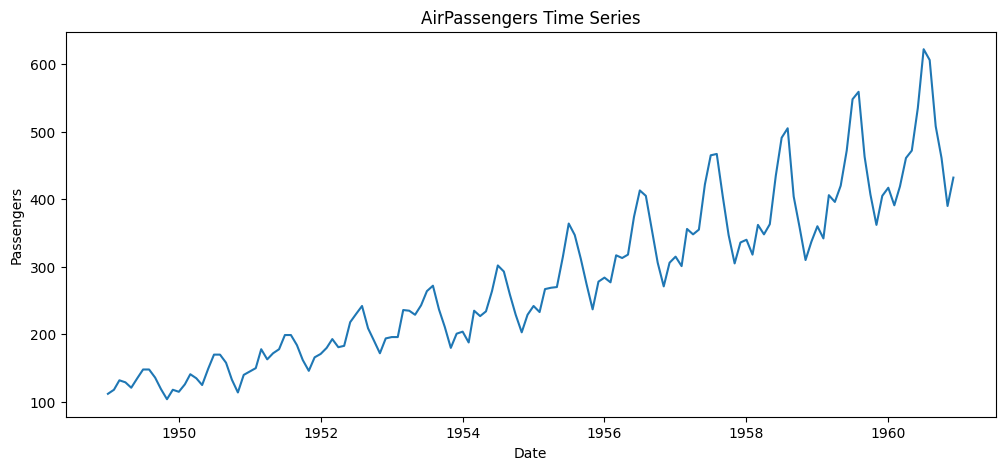

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y)

plt.title("AirPassengers Time Series")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.show()

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [14]:
result=seasonal_decompose(y,model='multiplicative')

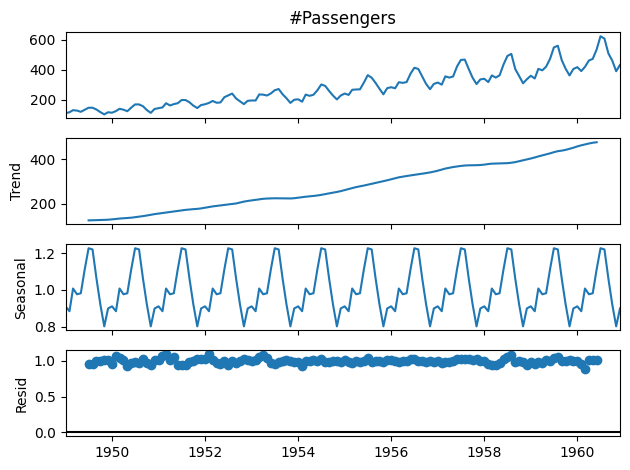

In [15]:
result.plot()

plt.show()

In [16]:
from statsmodels.tsa.stattools import adfuller,kpss

In [17]:
adf_test=adfuller(y)

In [18]:
print(f"adf stats:{round(adf_test[0],3)}")
print(f"p-value stats:{round(adf_test[1],3)}")

adf stats:0.815
p-value stats:0.992


In [19]:
train=y[:-24]
test=y[-24:]

In [20]:
train.shape

(120,)

In [21]:
test.shape

(24,)

In [22]:
from statsmodels.tsa.forecasting.theta import ThetaModel
#what does θ (theta) mean in the Theta model?”, it's the parameter that controls the curvature of the time series.

In [23]:
model = ThetaModel(
    train,
    deseasonalize=True,
    period=12
)

result = model.fit()

print(result)

In [24]:
# θ = 0  → removes curvature → long-term trend
# θ = 1  → original curvature
# θ = 2  → amplifies curvature

In [25]:
forecast = result.forecast(24)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\forecasting\theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


In [26]:
forecast.index=test.index

In [27]:
forecast

Month
1959-01-01    341.615217
1959-02-01    335.570557
1959-03-01    385.394604
1959-04-01    370.124982
1959-05-01    371.182194
1959-06-01    423.493240
1959-07-01    464.310513
1959-08-01    460.881124
1959-09-01    408.718121
1959-10-01    355.761391
1959-11-01    310.403984
1959-12-01    351.423738
1960-01-01    355.206661
1960-02-01    348.877391
1960-03-01    400.626843
1960-04-01    384.705684
1960-05-01    385.756698
1960-06-01    440.067510
1960-07-01    482.423178
1960-08-01    478.801752
1960-09-01    424.559144
1960-10-01    369.505535
1960-11-01    322.357351
1960-12-01    364.913447
Name: forecast, dtype: float64

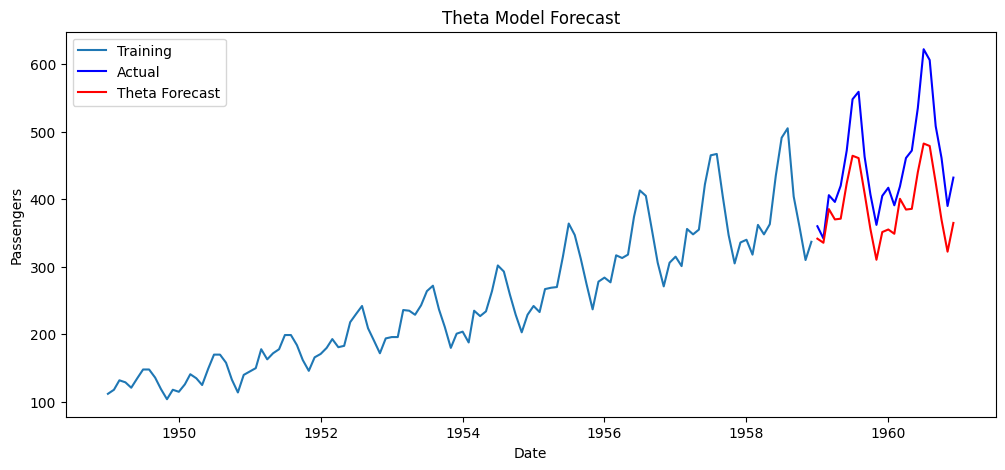

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(train, label="Training")
plt.plot(test, label="Actual", color="blue")
plt.plot(forecast, label="Theta Forecast", color="red")

plt.title("Theta Model Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.legend()
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mape = np.mean(
    np.abs((test - forecast) / test)
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE : 63.221630803808466
RMSE: 71.36096295521779
MAPE: 13.343084224672145 %


In [30]:
print(data.index)

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)


In [31]:
data=data.asfreq('MS')

In [32]:
final_model = ThetaModel(
    data,
    deseasonalize=True,
    period=12
)

In [33]:
final_result = final_model.fit()

In [34]:
future_forecast = final_result.forecast(12)

print(future_forecast)

1961-01-01    440.067925
1961-02-01    428.374315
1961-03-01    489.695737
1961-04-01    475.693621
1961-05-01    479.659320
1961-06-01    545.353722
1961-07-01    602.738168
1961-08-01    601.087004
1961-09-01    523.939531
1961-10-01    456.616749
1961-11-01    397.944699
1961-12-01    447.634771
Freq: MS, Name: forecast, dtype: float64


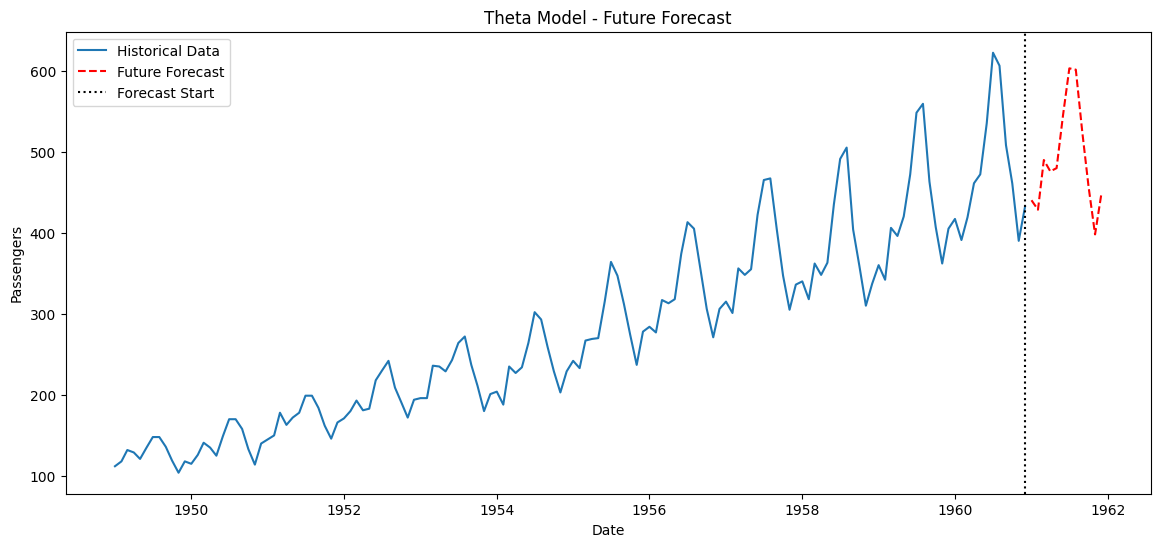

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    y,
    label="Historical Data"
)

plt.plot(
    future_forecast,
    label="Future Forecast",
    color="red",
    linestyle="--"
)

plt.axvline(
    y.index[-1],
    color="black",
    linestyle=":",
    label="Forecast Start"
)

plt.title("Theta Model - Future Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()

plt.show()